# Punto 2: Ecuación de Ergun

## Enunciado

La ecuación de Ergun, que se da abajo, sirve para describir el flujo de un líquido a través de un lecho empacado. ΔP es la caída de presión, ρ es la densidad del fluido, G₀ es la velocidad másica (el cociente del flujo de masa dividido entre el área de la sección transversal), Dₚ es el diámetro de las partículas dentro del lecho, μ es la viscocidad del fluido, L es la longitud del lecho y ε es la fracción vacía del lecho.

$$\frac{\Delta P \cdot \rho \cdot D_p}{G_o^2 \cdot L}\frac{\varepsilon^3}{(1-\varepsilon)} = 150 \frac{(1-\varepsilon)}{D_p G_o / \mu} + 1.75$$

1. Realizar el bosquejo de la grafica de la funcion de ceros

2. Dados los siguientes valores para los parametros encuentre la fraccion vacıa ε del lecho, use
el metodo de Biseccion.
- $\frac{D_p G_o}{\mu} = 1000$
- $\frac{\Delta P \cdot \rho \cdot D_p}{G_o^2 \cdot L} = 10$

3. Dados los siguientes valores para los parametros encuentre la fraccion vacıa ε del lecho, use
el metodo de la Secante.
- $\frac{D_p G_o}{\mu} = 1000$
- $\frac{\Delta P \cdot \rho \cdot D_p}{G_o^2 \cdot L} = 10$

4. De una justificacion de su respuesta

## Formulación de la función de ceros

Sustituyendo los valores dados en la ecuación de Ergun:

$$10 \cdot \frac{\varepsilon^3}{1-\varepsilon} = 150 \cdot \frac{1-\varepsilon}{1000} + 1.75$$

Simplificando:

$$10 \cdot \frac{\varepsilon^3}{1-\varepsilon} = 0.15(1-\varepsilon) + 1.75$$

La función de ceros es:

$$f(\varepsilon) = 10 \cdot \frac{\varepsilon^3}{1-\varepsilon} - 0.15(1-\varepsilon) - 1.75 = 0$$

Donde $0 < \varepsilon < 1$ (fracción vacía debe estar entre 0 y 1).

## Justificación del intervalo (0 < ε < 1)

El parámetro $\varepsilon$ representa la **fracción vacía del lecho**, es decir, la proporción de espacio vacío respecto al volumen total.

Se define como:

$$
\varepsilon = \frac{V_{vacío}}{V_{total}}
$$

Por esta definición:

- $\varepsilon = 0$ → no hay espacio vacío (todo son partículas).
- $\varepsilon = 1$ → todo es espacio vacío.

Por lo tanto, el valor de $\varepsilon$ siempre cumple:

$$
0 < \varepsilon < 1
$$

In [6]:
f = lambda e: 10*((e**3)/(1-e))-0.15*(1-e)-1.75
print("Evaluación de la función en algunos puntos:")
for eps in [0.3, 0.4, 0.45, 0.5, 0.6]:
    print(f"f({eps}) = {f(eps)}")

Evaluación de la función en algunos puntos:
f(0.3) = -1.4692857142857143
f(0.4) = -0.7733333333333329
f(0.45) = -0.17568181818181827
f(0.5) = 0.6749999999999998
f(0.6) = 3.59


# 1. Bosquejo de la gráfica

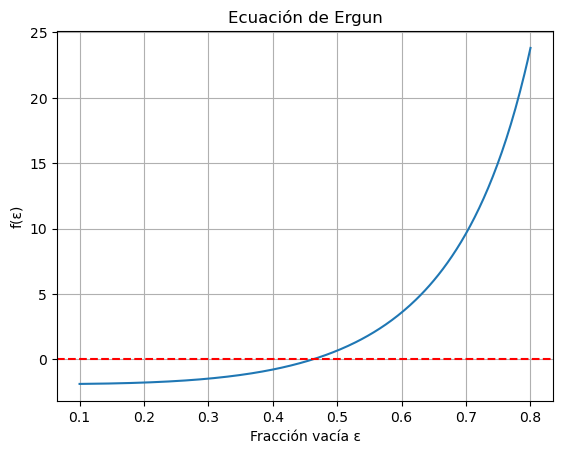

In [7]:
import numpy as np
import matplotlib.pyplot as plt

epsilon = np.linspace(0.1, 0.8, 300)
y = f(epsilon)

plt.plot(epsilon, y)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fracción vacía ε')
plt.ylabel('f(ε)')
plt.title('Ecuación de Ergun')
plt.grid()
plt.show()

## 2. Solución usando el Método de Bisección

La bisección encuentra una raíz dividiendo repetidamente un intervalo donde la función cambia de signo.

Aplicamos el método de bisección con el intervalo identificado en la gráfica.
Usamos la función `biseccion`.

In [8]:
from ceros_de_funcion import biseccion

resultado = biseccion(f, 0.1, 0.9)
print(f"La solucion de la funcion es: {resultado[0]}")

La solucion de la funcion es: 0.4625


## 3. Solución usando el Método de la Secante

El método de la secante es similar al de Newton-Raphson, pero aproxima la derivada usando dos puntos anteriores, evitando así el cálculo explícito de f'(x).

Fórmula iterativa:
$$x_{n+1} = x_n - f(x_n) \cdot \frac{x_n - x_{n-1}}{f(x_n) - f(x_{n-1})}$$

Aplicamos el método de la secante con dos valores iniciales cercanos a la raíz.

In [9]:
from ceros_de_funcion import secante

resultado = secante(f, 0.4, 0.5, 1e-6)
print(f"La solucion de la funcion es: {resultado}")

La solucion de la funcion es: 0.46185628340317


## 4. Justificación de la respuesta

Con la función
$$
f(\varepsilon)=10\frac{\varepsilon^3}{1-\varepsilon}-0.15(1-\varepsilon)-1.75, \quad 0<\varepsilon<1
$$
se obtuvo numéricamente una raíz aproximada
$$
\varepsilon \approx 0.462
$$

**Verificación numérica**
Al reemplazar $\varepsilon = 0.462$, se obtiene $f(\varepsilon) \approx 0$.
El residuo es muy pequeño (del orden de la tolerancia usada), por lo que satisface la ecuación de Ergun.

**Consistencia entre métodos**
- Bisección y secante convergen al mismo valor aproximado de $\varepsilon$.
- Esto respalda que la solución encontrada es estable y correcta.

**Justificación matemática de unicidad en el intervalo físico**
En $0<\varepsilon<1$:
$$
f'(\varepsilon)=10\frac{\varepsilon^2(3-2\varepsilon)}{(1-\varepsilon)^2}+0.15>0
$$
Luego, $f$ es estrictamente creciente en todo el intervalo físico, así que solo existe una raíz en $(0,1)$.

Por tanto, la fracción vacía del lecho queda justificada como:
$$
\boxed{\varepsilon \approx 0.462}
$$